In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [4]:
test_dir = "../data/processed/test"

In [5]:
test_transforms = transforms.Compose([
    
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [6]:
test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transforms
)

In [7]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [8]:
class BrainTumorCNN(nn.Module):
    
    def __init__(self):
        
        super(BrainTumorCNN, self).__init__()
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        
        self.classifier = nn.Sequential(
            
            nn.Flatten(),
            
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            
            nn.Linear(512, 4)
        )
    
    
    def forward(self, x):
        
        x = self.features(x)
        
        x = self.classifier(x)
        
        return x

In [9]:
model = BrainTumorCNN().to(device)

model.load_state_dict(
    torch.load("../models/baseline_cnn.pth")
)

model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [10]:
correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        
        outputs = model(images)
        
        
        _, predicted = torch.max(outputs, 1)
        
        
        total += labels.size(0)
        
        correct += (predicted == labels).sum().item()
        
        
        all_labels.extend(labels.cpu().numpy())
        
        all_predictions.extend(predicted.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 91.75%


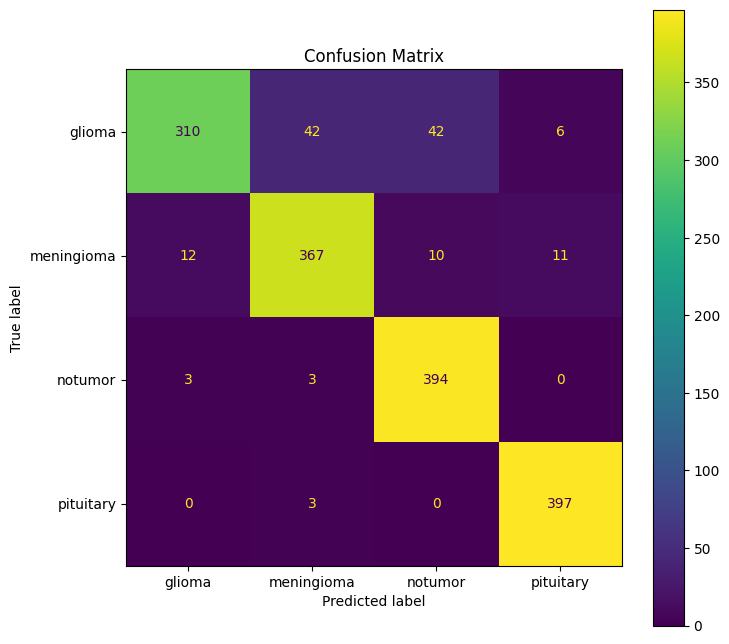

In [11]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.savefig("../results/figures/confusion_matrix.png")

plt.show()

In [12]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes
)

print(report)

              precision    recall  f1-score   support

      glioma       0.95      0.78      0.86       400
  meningioma       0.88      0.92      0.90       400
     notumor       0.88      0.98      0.93       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [13]:
with open("../results/logs/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.


In [14]:
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)
        
        
        wrong = predicted != labels
        
        
        misclassified_images.extend(images[wrong].cpu())
        misclassified_labels.extend(labels[wrong].cpu())
        misclassified_preds.extend(predicted[wrong].cpu())

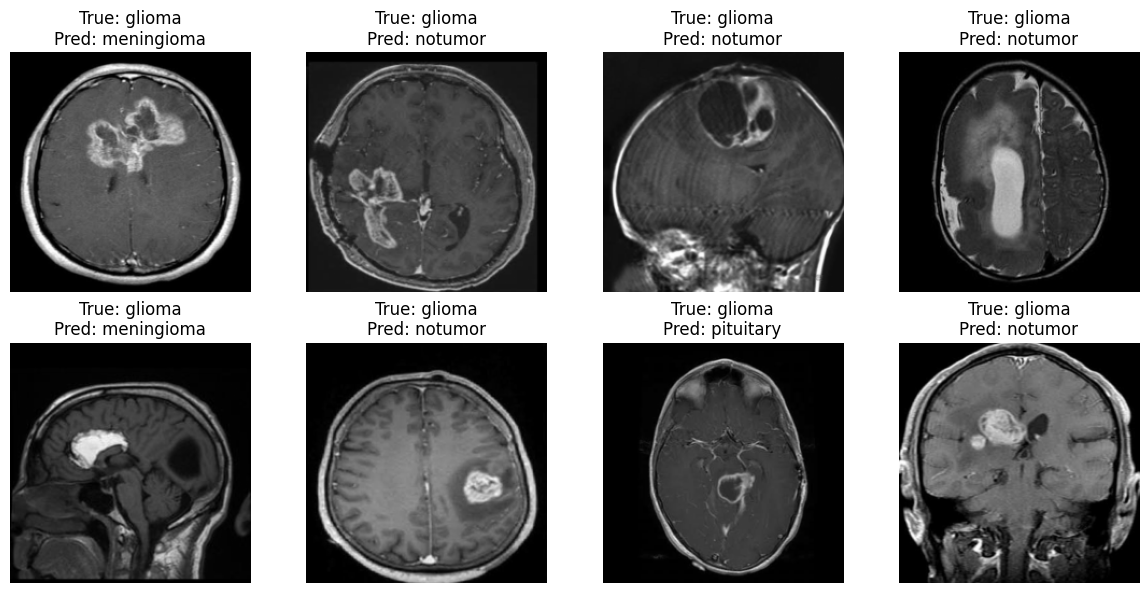

In [15]:
classes = test_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i in range(8):
    
    image = misclassified_images[i]
    
    image = image / 2 + 0.5
    
    np_image = image.numpy()
    
    true_label = classes[misclassified_labels[i]]
    
    pred_label = classes[misclassified_preds[i]]
    
    
    axes[i//4, i%4].imshow(np.transpose(np_image, (1,2,0)))
    
    axes[i//4, i%4].set_title(
        f"True: {true_label}\nPred: {pred_label}"
    )
    
    axes[i//4, i%4].axis('off')

plt.tight_layout()

plt.savefig("../results/figures/misclassified_examples.png")

plt.show()